<a href="https://colab.research.google.com/github/miso-20/ESSA/blob/main/ESAA_OB_2%EC%A1%B0_Project(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

##데이터 전처리 세팅

In [2]:
train = pd.read_csv('/content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/train.csv')
test = pd.read_csv('/content/drive/MyDrive/ESAA_OB/OB_data/Project(1)/test.csv')

In [3]:
X_train = train.drop(columns=['ID', 'target'])
y_train = train['target']
X_test = test.drop(columns=['ID'])

###데이터 스케일링

In [4]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

##EDA 및 피처 엔지니어링

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_4665/4159123429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='X_28', data=train, palette='viridis')


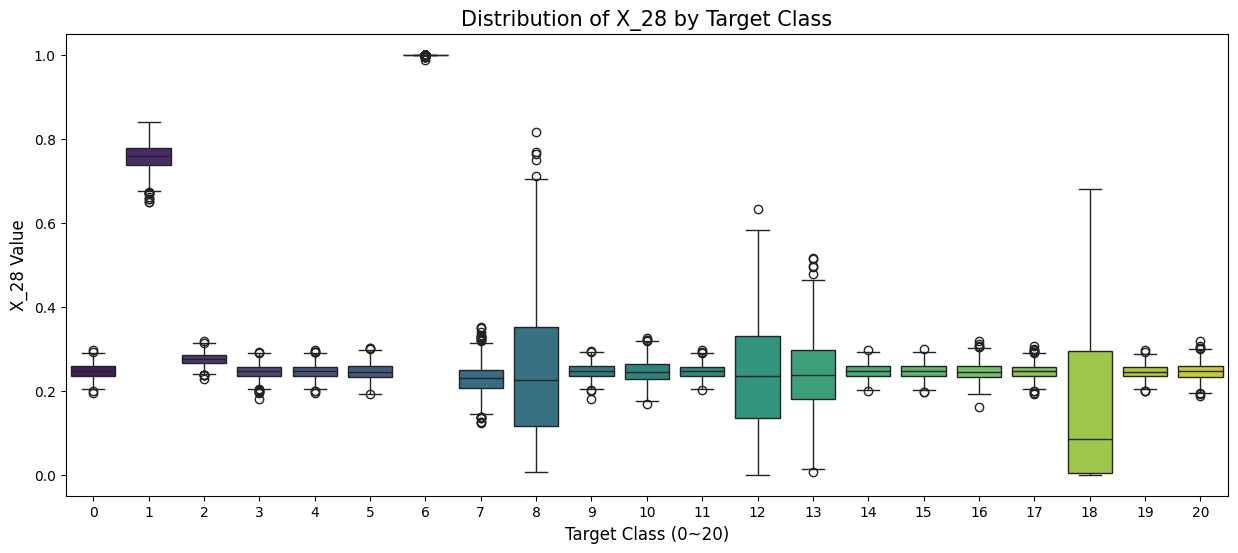

In [6]:
# 타겟별로 상관성이 가장 높았던 X_28 변수의 분포 차이 확인
plt.figure(figsize=(15, 6))
sns.boxplot(x='target', y='X_28', data=train, palette='viridis')
plt.title('Distribution of X_28 by Target Class', fontsize=15)
plt.xlabel('Target Class (0~20)', fontsize=12)
plt.ylabel('X_28 Value', fontsize=12)
plt.show()

###다중공선성 확인 및 중복 변수 제거

In [7]:
redundant_cols = ['X_17', 'X_45']  # X_10과 X_06과 각각 중복됨

X_train_clean = X_train_scaled.drop(columns=redundant_cols)
X_test_clean = X_test_scaled.drop(columns=redundant_cols)
print(f"중복 변수 제거 후 피처 개수: {X_train_clean.shape[1]}개")

중복 변수 제거 후 피처 개수: 50개


###VIF(분산팽창지수) 계산

In [8]:
vif = pd.DataFrame()
vif["Feature"] = X_train_clean.columns
vif["VIF Factor"] = [variance_inflation_factor(X_train_clean.values, i) for i in range(X_train_clean.shape[1])]
print("\n[VIF 상위 5개 변수 - 추가 제거 검토 필요]")
print(vif.sort_values(by="VIF Factor", ascending=False).head(5))


[VIF 상위 5개 변수 - 추가 제거 검토 필요]
   Feature    VIF Factor
48    X_51  15770.777513
4     X_05  13323.617722
36    X_38   1022.458630
23    X_25    896.834701
28    X_30    851.401827


###PCA로 차원 축소


In [9]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_clean)
X_test_pca = pca.transform(X_test_clean)

In [10]:
print(f"\n[PCA 요약]")
print(f"원본 특성 개수(중복제거 후): {X_train_clean.shape[1]}개")
print(f"95% 분산을 설명하는 데 필요한 주성분 개수: {X_train_pca.shape[1]}개")


[PCA 요약]
원본 특성 개수(중복제거 후): 50개
95% 분산을 설명하는 데 필요한 주성분 개수: 18개


In [11]:
pd.DataFrame(X_train_pca).to_csv('train_pca.csv', index=False)

### LightGBM

### XGBoost

### Random Forest

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_clean, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train shape: {X_tr.shape}, Validation shape: {X_val.shape}")

Train shape: (17354, 50), Validation shape: (4339, 50)


In [14]:
rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_base.fit(X_tr, y_tr)

val_pred_base = rf_base.predict(X_val)
print("[베이스라인 RF 성능]")
print(f"Accuracy: {accuracy_score(y_val, val_pred_base):.4f}")
print(f"Macro F1: {f1_score(y_val, val_pred_base, average='macro'):.4f}")
print(classification_report(y_val, val_pred_base))

[베이스라인 RF 성능]
Accuracy: 0.7714
Macro F1: 0.7741
              precision    recall  f1-score   support

           0       0.20      0.24      0.21       206
           1       1.00      1.00      1.00       206
           2       1.00      1.00      1.00       207
           3       0.32      0.47      0.38       206
           4       0.98      0.99      0.99       207
           5       1.00      1.00      1.00       206
           6       1.00      1.00      1.00       207
           7       1.00      1.00      1.00       207
           8       0.97      0.95      0.96       206
           9       0.16      0.16      0.16       207
          10       0.73      0.84      0.78       207
          11       0.96      0.86      0.91       206
          12       0.91      0.95      0.93       207
          13       0.99      0.93      0.96       207
          14       0.79      0.75      0.77       207
          15       0.22      0.20      0.21       206
          16       0.67      0.54

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

X_tr_sample = X_tr.sample(frac=0.15, random_state=42)
y_tr_sample = y_tr.loc[X_tr_sample.index]

print(f"튜닝용 샘플 크기: {X_tr_sample.shape}")

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_tr_sample, y_tr_sample)

print(f"\n[Best Params]\n{random_search.best_params_}")
print(f"[Best CV Macro F1 (샘플 기준)] {random_search.best_score_:.4f}")

best_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
best_rf.fit(X_tr, y_tr)

튜닝용 샘플 크기: (2603, 50)
Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
val_pred = best_rf.predict(X_val)

print("[튜닝된 RF - Validation 성능]")
print(f"Accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Macro F1: {f1_score(y_val, val_pred, average='macro'):.4f}")
print(classification_report(y_val, val_pred))